## Creating Lo-Fi data for small/large amplitude oscillatory shear (S/LAOS) rheometry
In this notebook, the synthetic generation of Lo-Fi data is introduced based on the given Hi-Fi data. This is a more intricate one as we need to introduce some form of physics to generate the Lo-Fi data.

First of all, we need to extract the time shift for each S/LAOS test. Note that the given data is in sheets. For each sheet, we need to extract the shifted time, maxietam strain, angular frequency, stress, strain, and strain rate, respectively, by calling the `extractor()` function.


### Importing dependencies

In [1]:
# Standard library
import os
import sys
from time import time

# Numerical / scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import odeint

# Scikit-learn core utilities
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.compose import TransformedTargetRegressor

# Scikit-learn models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor, RegressorChain

# Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# XGBoost
import xgboost as xgb


In [2]:
np.set_printoptions(suppress=True)
file = pd.ExcelFile(r"/home/alanh/projects/PunLab/mfnn/data/processed/pig_negcon/combined_pig_negcon.py.xlsx")

df = pd.read_excel(file, sheet_name=None)
data = [
    [k, v] for k, v in df.items() 
    if (v["Oscillation strain"].iloc[0] <= 5) & (v["Oscillation strain"].iloc[0] >= 0.01)
]  # NOTE: Adjust to include different sheets

# data.pop(23)  # Data incorrect in this sheet
t_train, g_train, w_train = np.array([]), np.array([]), np.array([])
s_train = np.array([])

def pos_finder(vector):
    crossings = np.where((vector[:-1] < 0) & (vector[1:] >= 0))[0]
    return crossings[0] + 1 if len(crossings) > 0 else np.argmin(np.abs(vector))    # ERROR: Not finding crossings?
    
def extractor(i):
    df_sheet = data[i][1].dropna()
    print(data[i][0])

    # Convert columns to arrays
    strain_raw = df_sheet['Strain'].to_numpy()
    time_raw = df_sheet['Step time'].to_numpy()
    stress_raw = df_sheet['Stress'].to_numpy()
    sr_raw = df_sheet['Shear rate'].to_numpy()
    w_raw = df_sheet['Angular frequency'].to_numpy()
    g0_raw = df_sheet['Oscillation strain'].to_numpy() 



    # Handling the time shift
    ind = pos_finder(strain_raw)
    print(f"Start Index (zero-crossing): {ind}")

    t0 = time_raw[ind]
    
    Time_adj = time_raw[ind:] - t0  # Now strictly starts at t=0
    St = strain_raw[ind:]
    Stress = stress_raw[ind:]
    SR = sr_raw[ind:]
    w = w_raw[ind:]
    G0 = g0_raw[ind:]
    
    return Time_adj, G0, w, Stress, St, SR

### Extracting $\tau$ and $\eta$
Then, you need to run the following cell for all sheets in `Data_HF_SAOS_raw.xlsx`. For each sheet, we fit a single-mode Maxwell VE model and extract $\tau$ and $\eta$ as a function of $\gamma_0$, $\omega$, and $t$. Note that we are using the `odeint` package, which is an ODE solver. Similar to other ODE solvers, we need initial condition (`y0`), `initial_guess`, and `bounds`. For each sheet, an appropriate `y0` is needed. For this particular sheet, `y0` is 90 Pa.

For this sheet, $\tau$ and $\eta$ are 0.16183 and0.14525, respectively. We do the same thing for all stress curves to obtain the following table:

--- Processing Sheet 0: 0.628rad - 0.022122 ---
0.628rad - 0.022122
Start Index (zero-crossing): 0


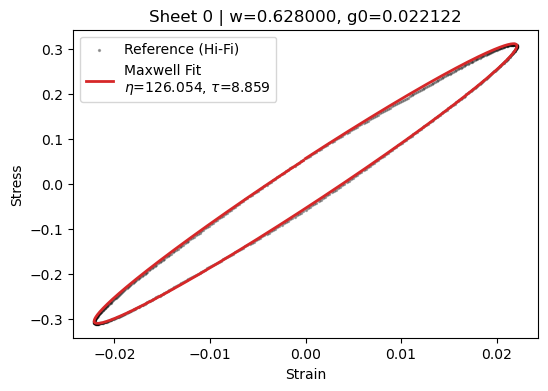

--- Processing Sheet 1: 0.628rad - 0.079266 ---
0.628rad - 0.079266
Start Index (zero-crossing): 0


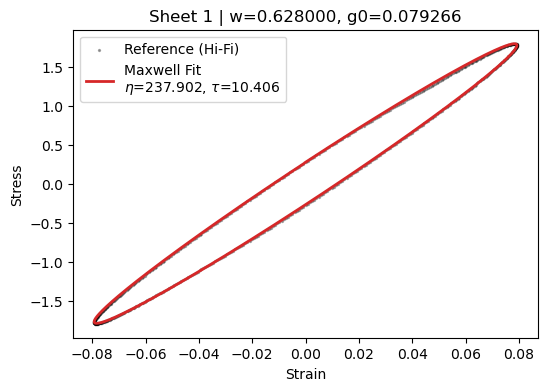

--- Processing Sheet 2: 0.628rad - 0.2624259 ---
0.628rad - 0.2624259
Start Index (zero-crossing): 0


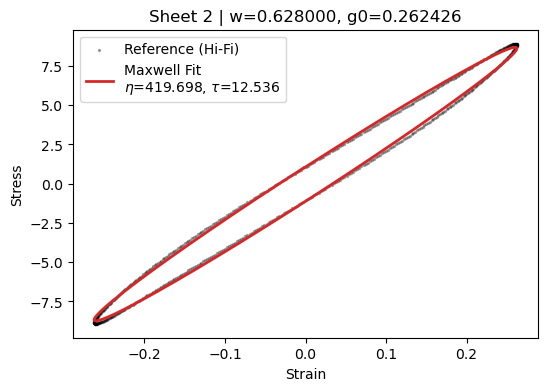

--- Processing Sheet 3: 0.628rad - 0.7242789 ---
0.628rad - 0.7242789
Start Index (zero-crossing): 0


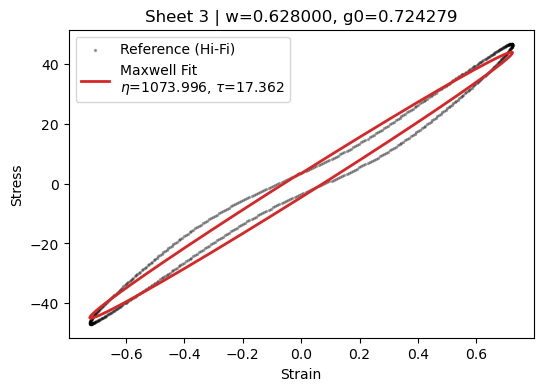

--- Processing Sheet 4: 0.628rad - 3.6871027 ---
0.628rad - 3.6871027
Start Index (zero-crossing): 0


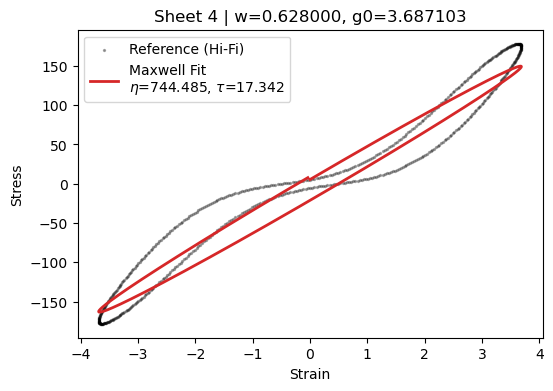

--- Processing Sheet 5: 0.628rad - 0.0233958 ---
0.628rad - 0.0233958
Start Index (zero-crossing): 0


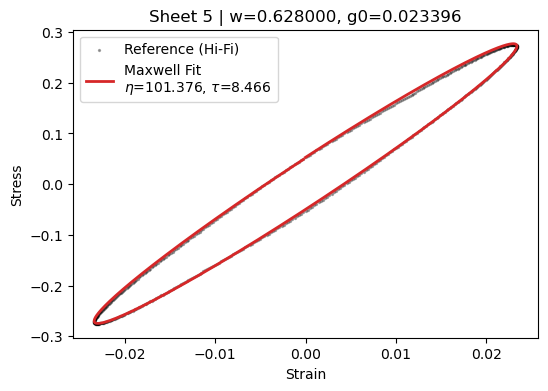

--- Processing Sheet 6: 0.628rad - 0.0808714 ---
0.628rad - 0.0808714
Start Index (zero-crossing): 0


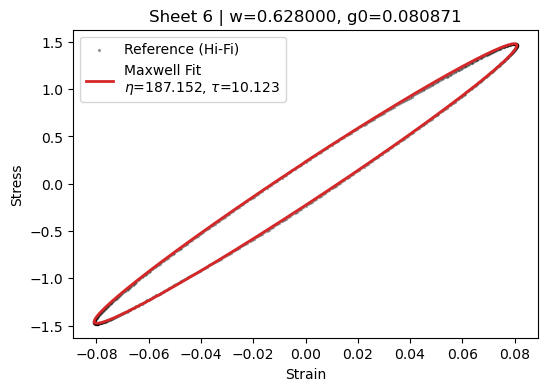

--- Processing Sheet 7: 0.628rad - 0.2615977 ---
0.628rad - 0.2615977
Start Index (zero-crossing): 0


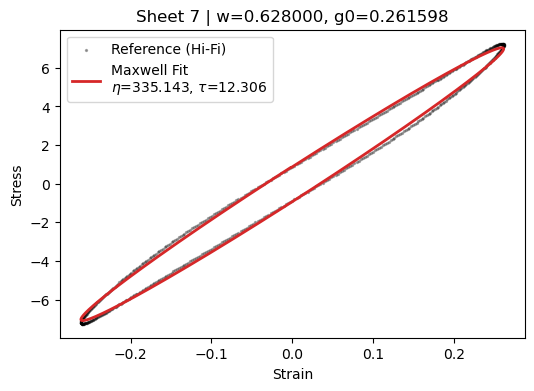

--- Processing Sheet 8: 0.628rad - 0.6944665 ---
0.628rad - 0.6944665
Start Index (zero-crossing): 0


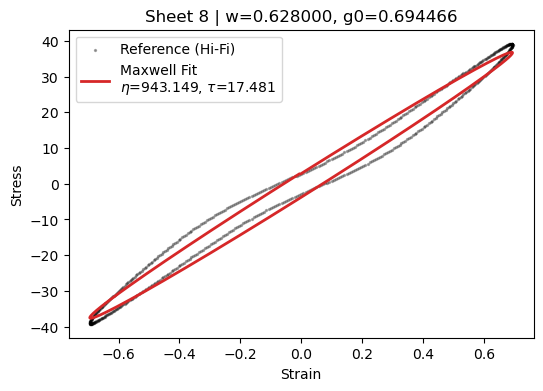

--- Processing Sheet 9: 0.628rad - 3.0372883 ---
0.628rad - 3.0372883
Start Index (zero-crossing): 0


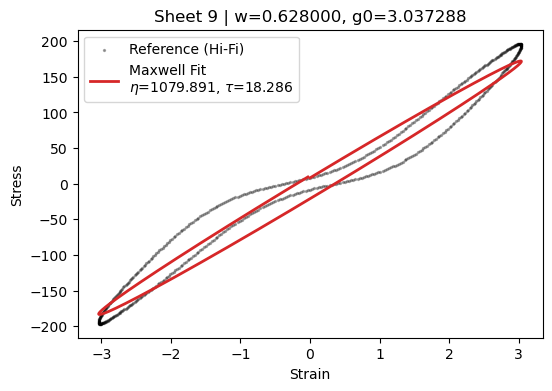

--- Processing Sheet 10: 0.628rad - 0.0252134 ---
0.628rad - 0.0252134
Start Index (zero-crossing): 0


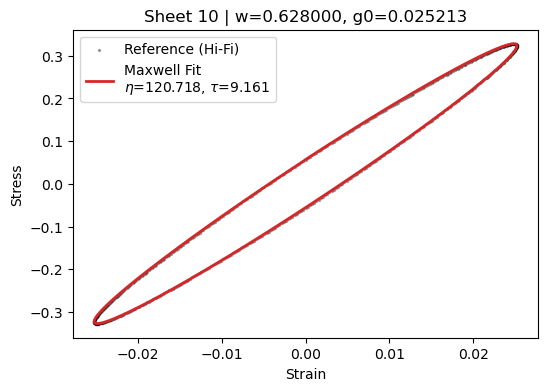

--- Processing Sheet 11: 0.628rad - 0.086821 ---
0.628rad - 0.086821
Start Index (zero-crossing): 0


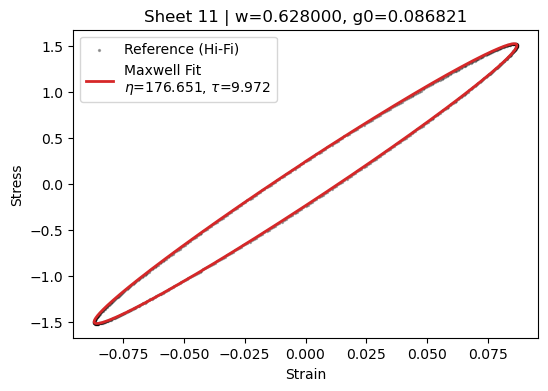

--- Processing Sheet 12: 0.628rad - 0.2788382 ---
0.628rad - 0.2788382
Start Index (zero-crossing): 0


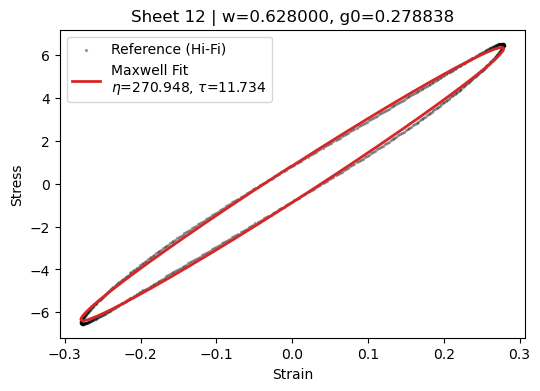

--- Processing Sheet 13: 0.628rad - 0.7593773 ---
0.628rad - 0.7593773
Start Index (zero-crossing): 0


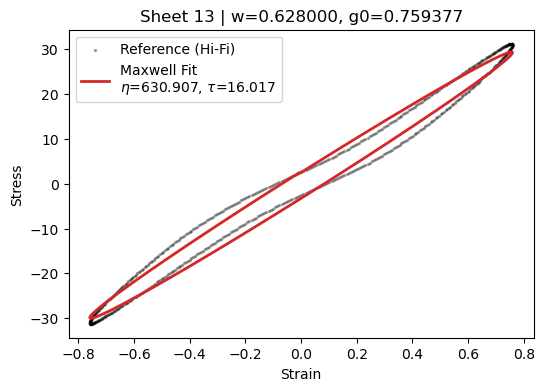

--- Processing Sheet 14: 0.628rad - 4.1893049 ---
0.628rad - 4.1893049
Start Index (zero-crossing): 0


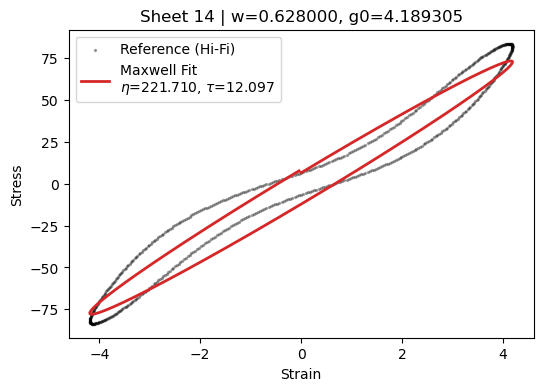

--- Processing Sheet 15: 0.628rad - 0.0255513 ---
0.628rad - 0.0255513
Start Index (zero-crossing): 0


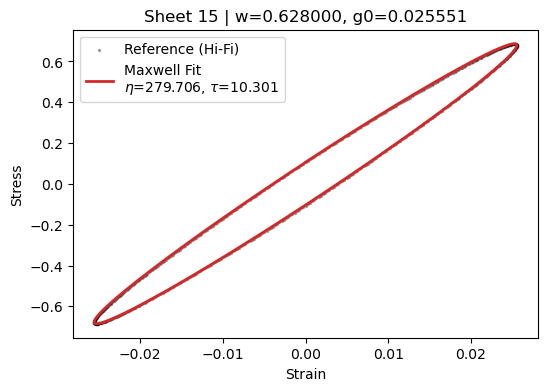

--- Processing Sheet 16: 0.628rad - 0.0872575 ---
0.628rad - 0.0872575
Start Index (zero-crossing): 0


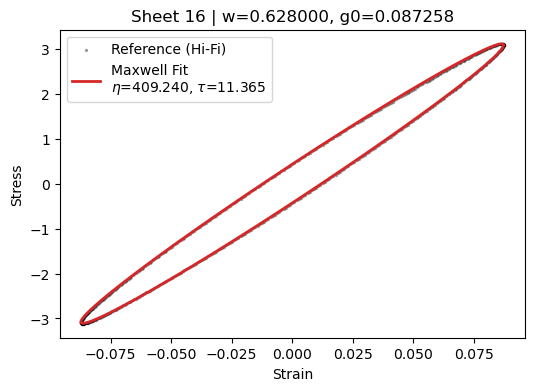

--- Processing Sheet 17: 0.628rad - 0.2741326 ---
0.628rad - 0.2741326
Start Index (zero-crossing): 0


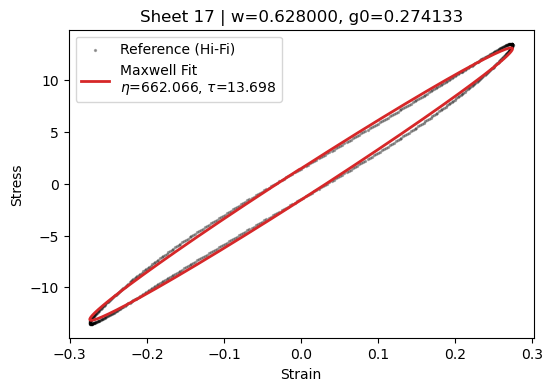

--- Processing Sheet 18: 0.628rad - 0.7396461 ---
0.628rad - 0.7396461
Start Index (zero-crossing): 0


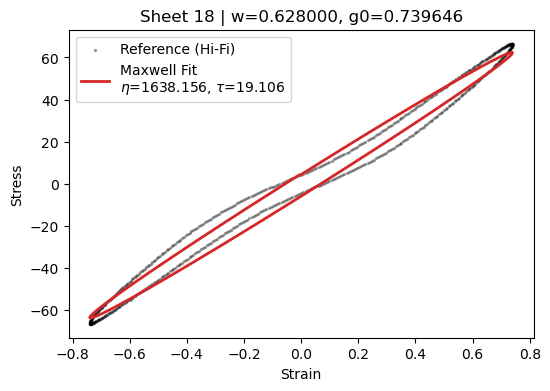

--- Processing Sheet 19: 0.628rad - 2.3593654 ---
0.628rad - 2.3593654
Start Index (zero-crossing): 0


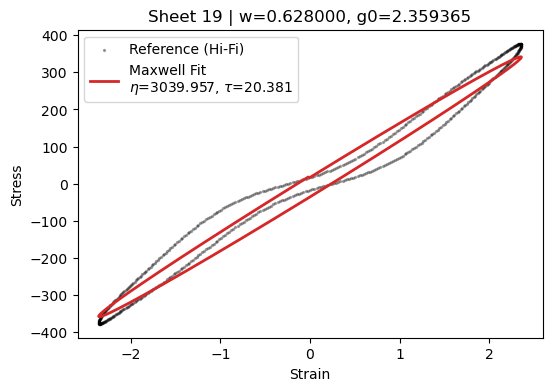

--- Processing Sheet 20: 0.628rad - 0.0232108 ---
0.628rad - 0.0232108
Start Index (zero-crossing): 0


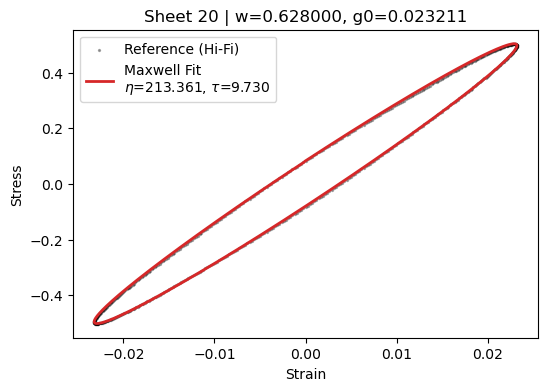

--- Processing Sheet 21: 0.628rad - 0.0834978 ---
0.628rad - 0.0834978
Start Index (zero-crossing): 0


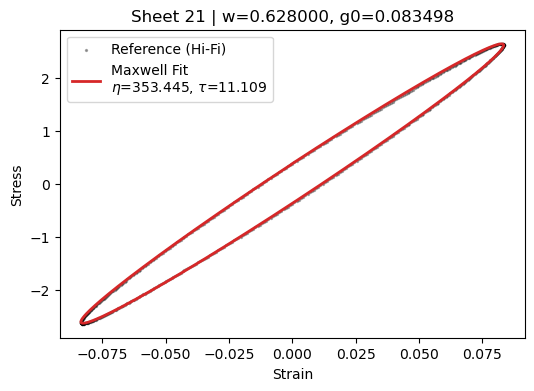

--- Processing Sheet 22: 0.628rad - 0.2718309 ---
0.628rad - 0.2718309
Start Index (zero-crossing): 0


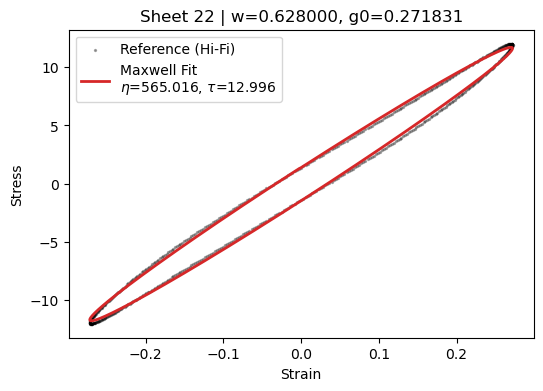

--- Processing Sheet 23: 0.628rad - 0.7946087 ---
0.628rad - 0.7946087
Start Index (zero-crossing): 0


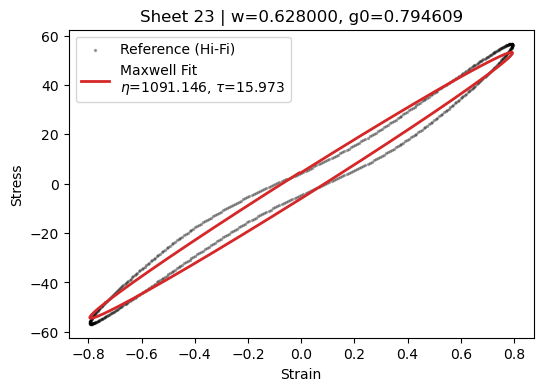


Y_fit (eta, tau):
array([[ 126.05425377,    8.85917207],
       [ 237.90218967,   10.40644991],
       [ 419.69792931,   12.53630743],
       [1073.99626761,   17.36237998],
       [ 744.48456204,   17.34156616],
       [ 101.37583043,    8.46603596],
       [ 187.15192017,   10.12288629],
       [ 335.14299305,   12.30605511],
       [ 943.14922787,   17.48058463],
       [1079.89097529,   18.28572619],
       [ 120.71823044,    9.16075877],
       [ 176.65143087,    9.97187842],
       [ 270.94759483,   11.73431213],
       [ 630.90692194,   16.0174451 ],
       [ 221.71004474,   12.09669205],
       [ 279.70649221,   10.30063293],
       [ 409.24016361,   11.36516622],
       [ 662.06583673,   13.69786279],
       [1638.1558267 ,   19.10606549],
       [3039.95740572,   20.38058708],
       [ 213.36071704,    9.7299696 ],
       [ 353.44549913,   11.10917182],
       [ 565.01562124,   12.99572148],
       [1091.14593551,   15.97343485]])

X_fit (omega, g0):
array([[0.628    , 0.022

In [3]:
# ODE INT

# Initialize lists to store the results from all sheets
Y_fit_list = []
X_fit_list = []
y0_fit_list = []

# Lookup dict keyed by sheet index  # NOTE: Added this to fix lf_set array. Maybe remove list?
X_fit_dict  = {}   # sheet_idx -> [omega, g0]
Y_fit_dict  = {}   # sheet_idx -> [eta, tau]
y0_fit_dict = {}   # sheet_idx -> y0


# Define the ODE function (relies on global g0, omega, which we update in the loop)
def maxwell_ve(y, t, eta, tau, g0, omega, tmax, wmax):
    gdot = g0 * omega * np.cos(omega * t * tmax * wmax)
    dydt = (1.0 / tau) * (eta * gdot - y)
    return dydt


def fit_function(t, eta, tau, y0, g0, omega, tmax, wmax):
    y_pred = odeint(maxwell_ve, y0, t, args=(eta, tau, g0, omega, tmax, wmax))
    return y_pred[:, 0]


# Loop over all sheets
for i in range(len(data)):
    print(f"--- Processing Sheet {i}: {data[i][0]} ---")
    
    # Extract data for this specific sheet
    t_train, g_train, w_train, s_train, st_train, sr_train = extractor(i)
    
    # Normalization settings: ONLY NEEDED FOR MLP Regressor
    Norm = False
    if Norm:
        tmax = max(t_train)
        gmax = max(g_train)
        wmax = max(w_train)
        smax = max(s_train)
        t_train, g_train, w_train, s_train = t_train/tmax, g_train/gmax, w_train/wmax, s_train/smax
    else:
        tmax = 1.
        gmax = 1.
        wmax = 1.
        smax = 1.

    # Get relevant maxwell variables
    assert len(np.unique(g_train)) == 1
    assert len(np.unique(w_train)) == 1
    g0 = np.unique(g_train)[0]
    omega = np.unique(w_train)[0]
    y0 = s_train.iloc[0] if hasattr(s_train, 'iloc') else s_train[0]
    
    # Setup fitting vectors
    t = t_train
    y = s_train
    g = g0 * np.sin(omega * t_train * tmax * wmax)  # Theoretical strain ONLY for plotting, should be fine to use st_train with SPP

    # Wrapper to freeze extra variables
    fit_wrapper = lambda t_val, eta_val, tau_val: fit_function(
        t_val, eta_val, tau_val,
        y0, g0, omega, tmax, wmax
    )

    # Make initial guess and bounds
    stress_amp = (np.max(s_train) - np.min(s_train)) / 2.0
    eta_guess = stress_amp / (g0 * omega)
    tau_guess = 1.0 / omega
    initial_guess = [eta_guess, tau_guess]
    
    # Perform the Fit
    bounds = ([0.0, 0.0], [np.inf, np.inf])
    try:
        fit_params, covariance = curve_fit(fit_wrapper, t, y,
                                           p0=initial_guess,
                                           bounds=bounds,
                                           method='trf',
                                           maxfev=5000)
        eta_fit, tau_fit = fit_params
    except RuntimeError:
        print(f"Fit failed for sheet {i}. Using zeros.")
        eta_fit, tau_fit = 0.0, 0.0

    # Append results
    Y_fit_list.append([eta_fit, tau_fit])   # Y_fit stores [eta, tau]
    X_fit_list.append([omega, g0])  # X_fit stores [omega, g0]
    y0_fit_list.append(y0)  # y0_fit stores the initial stress

    X_fit_dict[i]  = [omega, g0]
    Y_fit_dict[i]  = [eta_fit, tau_fit]
    y0_fit_dict[i] = y0

    # Plot
    y_predicted = fit_function(t, eta_fit, tau_fit, y0, g0, omega, tmax, wmax)
    
    plt.figure(figsize=(6, 4))
    plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
    plt.scatter(g, y, label='Reference (Hi-Fi)', s=2, color='k', alpha=0.3)
    plt.plot(g, y_predicted, '-', label=f'Maxwell Fit\n$\eta$={eta_fit:.3f}, $\\tau$={tau_fit:.3f}', linewidth=2, color='tab:red')
    plt.xlabel('Strain')
    plt.ylabel('Stress')
    plt.legend()
    plt.show()
    plt.close()

# Convert lists to numpy arrays for the next steps
Y_fit = np.array(Y_fit_list)
X_fit = np.array(X_fit_list)
y0_fit = np.array(y0_fit_list)

print("\nY_fit (eta, tau):")
print(repr(Y_fit))
print("\nX_fit (omega, g0):")
print(repr(X_fit))
print("\ny0_fit (initial stress):")
print(repr(y0_fit))

### Masking Hi-Fi data
Here, and depending on which stress loop we wish to omit from MFNN training, we select from `hf_set`.

In [4]:
# Use train_test_split to create a 20% "masking" set
# 'indices' will allow us to map back to Y_fit and y0_fit easily
indices = np.arange(len(X_fit))
X_all = X_fit
Y_all = Y_fit
y_00_all = y0_fit

# idx_train, idx_test = train_test_split(indices, test_size=0.20, random_state=8)

# X_train = X_fit[idx_train]
# Y_train = Y_fit[idx_train]
# y_00_train  = y0_fit[idx_train]

# X_test = X_fit[idx_test]
# Y_test = Y_fit[idx_test]
# y_00_test  = y0_fit[idx_test]


# print('\nThe masked set(s) are:\n', idx_test)

### Regression of $\tau$ and $\eta$ on $\gamma_0$ and $\omega$

Here, we have several options to select the regression kernel. The output of this cell is the regressed $\tau$ and $\eta$ values for each kernel.

Tuning XGBoost for eta...
Fitting 24 folds for each of 30 candidates, totalling 720 fits

Tuning XGBoost for tau...
Fitting 24 folds for each of 30 candidates, totalling 720 fits

Best eta params: {'subsample': 0.6, 'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.4}
Best tau params: {'subsample': 0.6, 'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.05, 'colsample_bytree': 0.4}

--- LOO Cross-Validation Results ---
Eta | MSE (log): 0.319885 ± 0.420498
Tau | MSE (log): 0.015871 ± 0.028638

Eta | RMSE (log): 0.565584
Tau | RMSE (log): 0.125978

Eta | RMSE (original space): 524.6777
Tau | RMSE (original space): 1.8512


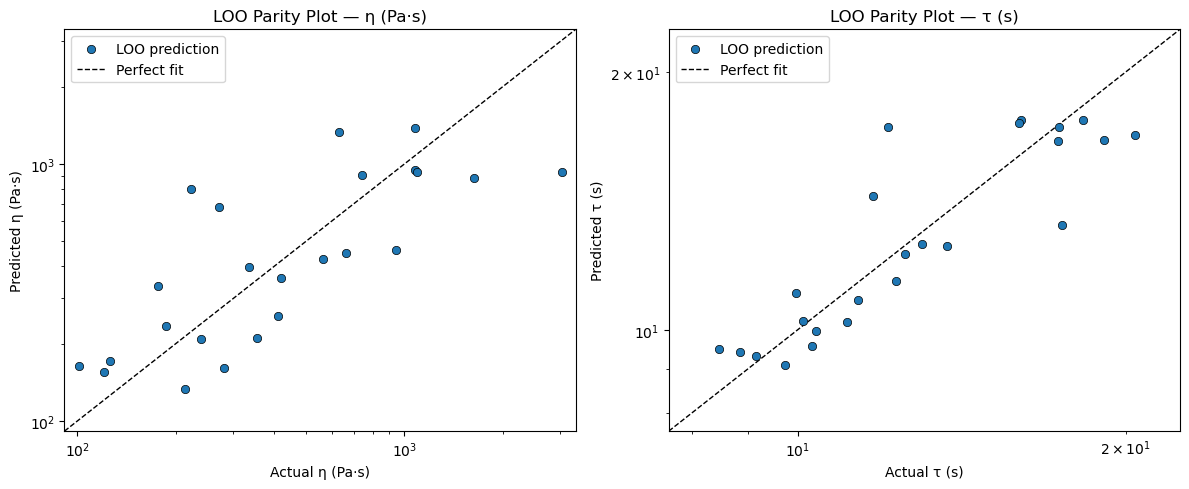


Actual parameters:
[[5.23192069 2.31479883]
 [5.81455729 2.51009143]
 [6.61269212 2.85310629]
 [5.63374081 2.33220534]
 [4.8367124  2.18145331]]
Second-Order Polynomial Regression Predictions:
[[5.74070676 2.42460316]
 [6.38304767 2.62377152]
 [6.76605131 2.83244978]
 [4.82793716 2.16543049]
 [4.6940857  2.12857263]]
Eta MSE:  0.255045104825683
Tau MSE:  0.011203412925012266

Random Forest Regression Predictions:
[[5.53393945 2.35327712]
 [6.15121868 2.54690941]
 [6.02281208 2.63620809]
 [4.8066041  2.20211665]
 [5.12517293 2.23728498]]
Eta MSE:  0.2639758594304616
Tau MSE:  0.013984242875440273


In [5]:
# QUESTION: Scale inputs as well?
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, test_size=0.1, random_state=8)

X_log = np.log(X_all)
Y_log = np.log(Y_all)
Y_log_eta = Y_log[:, 0]   # log(eta)
Y_log_tau = Y_log[:, 1]   # log(tau)

X_train_l, X_test_l, Y_train_l, Y_test_l = train_test_split(X_log, Y_log, test_size=0.2, random_state = 8)

xgb_eta = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_jobs=1,
    random_state=8,
    tree_method='hist'
)
xgb_tau = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_jobs=1,
    random_state=8,
    tree_method='hist'
)
param_dist = {
    'n_estimators':     [150, 300, 450, 600, 750],
    'max_depth':        [1, 2, 3, 4],
    'learning_rate':    [0.01, 0.05, 0.1],
    'colsample_bytree': [0.4, 0.6, 0.8, 1.0],
    'subsample':        [0.4, 0.6, 0.8, 1.0]
}

loo = LeaveOneOut()

# --- Tune eta model ---
print("Tuning XGBoost for eta...")
search_eta = RandomizedSearchCV(
    estimator=xgb_eta,
    param_distributions=param_dist,
    n_iter=30,
    cv=loo,                              # LOO instead of KFold
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=8
)
search_eta.fit(X_log, Y_log_eta)         # fit on ALL data — LOO handles splitting internally
best_eta_model = search_eta.best_estimator_


# --- Tune tau model ---
print("\nTuning XGBoost for tau...")
search_tau = RandomizedSearchCV(
    estimator=xgb_tau,
    param_distributions=param_dist,
    n_iter=30,
    cv=loo,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1,
    random_state=8
)
search_tau.fit(X_log, Y_log_tau)
best_tau_model = search_tau.best_estimator_

print(f"\nBest eta params: {search_eta.best_params_}")
print(f"Best tau params: {search_tau.best_params_}")


# --- LOO evaluation of final tuned models ---
# These scores use the best hyperparameters across all LOO folds
loo_scores_eta = cross_val_score(
    best_eta_model, X_log, Y_log_eta,
    cv=loo, scoring='neg_mean_squared_error', n_jobs=-1
)
loo_scores_tau = cross_val_score(
    best_tau_model, X_log, Y_log_tau,
    cv=loo, scoring='neg_mean_squared_error', n_jobs=-1
)

eta_loo_preds = np.zeros(len(Y_log_eta))
tau_loo_preds = np.zeros(len(Y_log_tau))


for train_idx, test_idx in loo.split(X_log):
    # eta
    best_eta_model.fit(X_log[train_idx], Y_log_eta[train_idx])
    eta_loo_preds[test_idx] = best_eta_model.predict(X_log[test_idx])
    # tau
    best_tau_model.fit(X_log[train_idx], Y_log_tau[train_idx])
    tau_loo_preds[test_idx] = best_tau_model.predict(X_log[test_idx])

best_eta_model.fit(X_log, Y_log_eta)
best_tau_model.fit(X_log, Y_log_tau)

print("\n--- LOO Cross-Validation Results ---")
print(f"Eta | MSE (log): {-loo_scores_eta.mean():.6f} ± {loo_scores_eta.std():.6f}")
print(f"Tau | MSE (log): {-loo_scores_tau.mean():.6f} ± {loo_scores_tau.std():.6f}")

print(f"\nEta | RMSE (log): {np.sqrt(-loo_scores_eta.mean()):.6f}")
print(f"Tau | RMSE (log): {np.sqrt(-loo_scores_tau.mean()):.6f}")

print(f"\nEta | RMSE (original space): {np.sqrt(mean_squared_error(np.exp(Y_log_eta), np.exp(eta_loo_preds))):.4f}")
print(f"Tau | RMSE (original space): {np.sqrt(mean_squared_error(np.exp(Y_log_tau), np.exp(tau_loo_preds))):.4f}")

# --- Parity plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, actual_log, pred_log, label in zip(
    axes,
    [Y_log_eta, Y_log_tau],
    [eta_loo_preds, tau_loo_preds],
    ['η (Pa·s)', 'τ (s)']
):
    actual_orig = np.exp(actual_log)
    pred_orig   = np.exp(pred_log)

    lims = [min(actual_orig.min(), pred_orig.min()) * 0.9,
            max(actual_orig.max(), pred_orig.max()) * 1.1]

    ax.scatter(actual_orig, pred_orig, color='tab:blue', edgecolors='k',
               linewidths=0.5, zorder=3, label='LOO prediction')
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'LOO Parity Plot — {label}')
    ax.legend()

plt.tight_layout()
plt.show()

poly_regressor = make_pipeline(PolynomialFeatures(degree=2), MultiOutputRegressor(LinearRegression()))
poly_regressor.fit(X_train_l, Y_train_l)
poly_predictions = poly_regressor.predict(X_test_l)

rf_regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=250, random_state=8))
rf_regressor.fit(X_train_l, Y_train_l)
rf_predictions = rf_regressor.predict(X_test_l)

# scaler_X = StandardScaler()
# X_scaled = scaler_X.fit_transform(X_fit)
# # Define Kernel
# # Constant * RBF (smoothness) + WhiteKernel (noise tolerance)
# kernel = C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
# gpr_regressor = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
# gpr_regressor.fit(X_scaled, Y_all)
# gpr_predictions = gpr_regressor.predict(X_scaled)

# X_pred_scaled = scaler_X.transform(np.reshape([omega, g0], (1,-1)))   
# log_preds = gpr.predict(X_pred_scaled)
# eta_pred, tau_pred = np.exp(log_preds[0])
# mlp_regressor = MultiOutputRegressor(MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20),
#                                                   max_iter=10000,
#                                                   random_state=4,
#                                                   solver='lbfgs',
#                                                  activation='tanh',
#                                                  alpha=1e-3))
# mlp_regressor.fit(X_train, Y_train)
# mlp_predictions = mlp_regressor.predict(X_train)

print("\nActual parameters:")
print(Y_test_l)

print("Second-Order Polynomial Regression Predictions:")
print(poly_predictions)
print("Eta MSE: ", mean_squared_error(Y_test_l[:, 0], poly_predictions[:, 0]))
print("Tau MSE: ", mean_squared_error(Y_test_l[:, 1], poly_predictions[:, 1]))

print("\nRandom Forest Regression Predictions:")
print(rf_predictions)
print("Eta MSE: ", mean_squared_error(Y_test_l[:, 0], rf_predictions[:, 0]))
print("Tau MSE: ", mean_squared_error(Y_test_l[:, 1], rf_predictions[:, 1]))
# print("\nGaussian Process Regression Predictions:")
# print(gpr_predictions)

# print("\nMLP Regression Predictions:")
# print(mlp_predictions)

In [6]:
# # QUESTION: Scale inputs as well?
# X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all, test_size=0.1, random_state=8)

# X_log = np.log(X_all)
# Y_log = np.log(Y_all)
# Y_log_eta = Y_log[:, 0]   # log(eta)
# Y_log_tau = Y_log[:, 1]   # log(tau)

# X_train_l, X_test_l, Y_train_l, Y_test_l = train_test_split(X_log, Y_log, test_size=0.2, random_state = 8)


# # xgb_base = xgb.XGBRegressor(
# #     objective='reg:squarederror',
# #     n_jobs=1,
# #     random_state=8,
# #     tree_method='hist'
# # )
# # chain = RegressorChain(estimator=xgb_base, order=[0, 1])
# # model = TransformedTargetRegressor(
# #     regressor=chain,
# #     func=np.log1p, 
# #     inverse_func=np.expm1
# # )
# # param_dist = {
# #     'regressor__estimator__n_estimators': [150, 300, 450, 600, 750], 
# #     'regressor__estimator__max_depth': [1, 2, 3, 4],       
# #     'regressor__estimator__learning_rate': [0.01, 0.05, 0.1],
# #     'regressor__estimator__colsample_bytree': [0.4, 0.6, 0.8, 1.0],
# #     'regressor__estimator__subsample': [0.4, 0.6, 0.8, 1.0]
# # }
# # search = RandomizedSearchCV(
# #     estimator=model,
# #     param_distributions=param_dist,
# #     n_iter=20,
# #     cv=5,
# #     scoring='neg_mean_squared_error',
# #     verbose=1,
# #     n_jobs=-1,
# #     random_state=8
# # )
# # print("Tuning RegressorChain...")
# # search.fit(X_train_l, Y_train_l)
# # best_model = search.best_estimator_
# # xgb_predictions = best_model.predict(X_test_l)

# # print(f"Best Parameters: {search.best_params_}")

# # eta_mse = mean_squared_error(Y_test_l[:, 0], xgb_predictions[:, 0])
# # tau_mse = mean_squared_error(Y_test_l[:, 1], xgb_predictions[:, 1])


# poly_regressor = make_pipeline(PolynomialFeatures(degree=2), MultiOutputRegressor(LinearRegression()))
# poly_regressor.fit(X_train_l, Y_train_l)
# poly_predictions = poly_regressor.predict(X_test_l)

# rf_regressor = MultiOutputRegressor(RandomForestRegressor(n_estimators=250, random_state=8))
# rf_regressor.fit(X_train_l, Y_train_l)
# rf_predictions = rf_regressor.predict(X_test_l)

# # scaler_X = StandardScaler()
# # X_scaled = scaler_X.fit_transform(X_fit)
# # # Define Kernel
# # # Constant * RBF (smoothness) + WhiteKernel (noise tolerance)
# # kernel = C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)
# # gpr_regressor = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
# # gpr_regressor.fit(X_scaled, Y_all)
# # gpr_predictions = gpr_regressor.predict(X_scaled)

# # X_pred_scaled = scaler_X.transform(np.reshape([omega, g0], (1,-1)))   
# # log_preds = gpr.predict(X_pred_scaled)
# # eta_pred, tau_pred = np.exp(log_preds[0])
# # mlp_regressor = MultiOutputRegressor(MLPRegressor(hidden_layer_sizes=(20, 20, 20, 20),
# #                                                   max_iter=10000,
# #                                                   random_state=4,
# #                                                   solver='lbfgs',
# #                                                  activation='tanh',
# #                                                  alpha=1e-3))
# # mlp_regressor.fit(X_train, Y_train)
# # mlp_predictions = mlp_regressor.predict(X_train)

# print("\nActual parameters:")
# print(Y_test_l)

# print("\nXGBoost Regression Predictions:")
# print(xgb_predictions)
# print(f"Eta MSE (Corrected): {eta_mse}")
# print(f"Tau MSE (Corrected): {tau_mse}")

# print("Second-Order Polynomial Regression Predictions:")
# print(poly_predictions)
# print("Eta MSE: ", mean_squared_error(Y_test_l[:, 0], poly_predictions[:, 0]))
# print("Tau MSE: ", mean_squared_error(Y_test_l[:, 1], poly_predictions[:, 1]))

# print("\nRandom Forest Regression Predictions:")
# print(rf_predictions)
# print("Eta MSE: ", mean_squared_error(Y_test_l[:, 0], rf_predictions[:, 0]))
# print("Tau MSE: ", mean_squared_error(Y_test_l[:, 1], rf_predictions[:, 1]))
# # print("\nGaussian Process Regression Predictions:")
# # print(gpr_predictions)

# # print("\nMLP Regression Predictions:")
# # print(mlp_predictions)

### Hi-Fi data extraction and sampling
Since we used the raw Hi-Fi data, we need to extract those shifted Hi-Fi data and use them for MFNN training. Also, the given Hi-Fi data was too dense, and we sample every 40 of them.

In [7]:
hf_set = indices

print(f"Training on {len(hf_set)} samples. Masking {len(indices)} samples.")
print(f"Masked Indices: {indices}")

t_hf_list, g0_hf_list, w_hf_list, g_hf_list, gdot_hf_list, s_hf_list = [], [], [], [], [], []

for i in hf_set:
    t_hf, g0_hf, w_hf, s_hf, st_hf, sr_hf = extractor(i)

    idx = np.arange(0, len(t_hf), 20)  # QUESTION: Changed from 40 to 20
    
    g0_hf_list.append(g0_hf[idx])
    t_hf_list.append(t_hf[idx])
    w_hf_list.append(w_hf[idx])
    
    g_hf_list.append(st_hf[idx])
    gdot_hf_list.append(sr_hf[idx])
    s_hf_list.append(s_hf[idx])


t_hf_sampled = np.concatenate(t_hf_list)
g0_hf_sampled = np.concatenate(g0_hf_list)
w_hf_sampled = np.concatenate(w_hf_list)
g_hf_sampled = np.concatenate(g_hf_list)
gdot_hf_sampled = np.concatenate(gdot_hf_list)
s_hf_sampled = np.concatenate(s_hf_list)

print(f"Final sampled data points: {len(s_hf_sampled)}")

Training on 24 samples. Masking 24 samples.
Masked Indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
0.628rad - 0.022122
Start Index (zero-crossing): 0
0.628rad - 0.079266
Start Index (zero-crossing): 0
0.628rad - 0.2624259
Start Index (zero-crossing): 0
0.628rad - 0.7242789
Start Index (zero-crossing): 0
0.628rad - 3.6871027
Start Index (zero-crossing): 0
0.628rad - 0.0233958
Start Index (zero-crossing): 0
0.628rad - 0.0808714
Start Index (zero-crossing): 0
0.628rad - 0.2615977
Start Index (zero-crossing): 0
0.628rad - 0.6944665
Start Index (zero-crossing): 0
0.628rad - 3.0372883
Start Index (zero-crossing): 0
0.628rad - 0.0252134
Start Index (zero-crossing): 0
0.628rad - 0.086821
Start Index (zero-crossing): 0
0.628rad - 0.2788382
Start Index (zero-crossing): 0
0.628rad - 0.7593773
Start Index (zero-crossing): 0
0.628rad - 4.1893049
Start Index (zero-crossing): 0
0.628rad - 0.0255513
Start Index (zero-crossing): 0
0.628rad - 0.0872575
Start Index (zer

Almost there. Now, for each set in `lf_set`, which is essentially all the loops, we call the `fit_function()` function, which predicts the linear VE stress response as a function of `t_pred`, `eta_pred`, and `tau_pred`. We then append every variable to an empty vector, and call that our Lo-Fi data. Keeping an eye on the top image as reference can also help. :)

0.628rad - 0.022122
Start Index (zero-crossing): 0


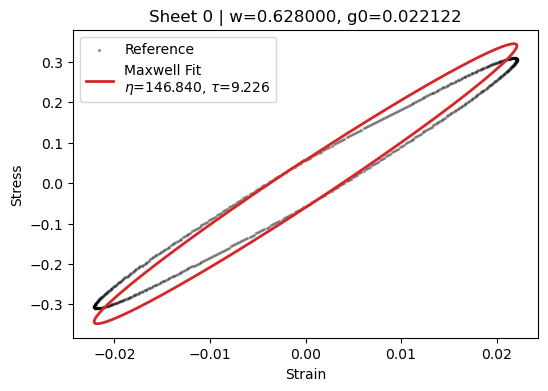

0.628rad - 0.079266
Start Index (zero-crossing): 0


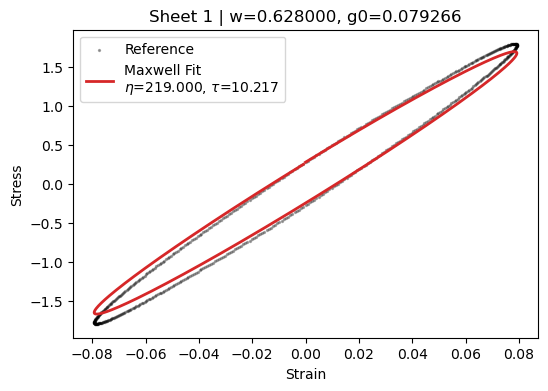

0.628rad - 0.2624259
Start Index (zero-crossing): 0


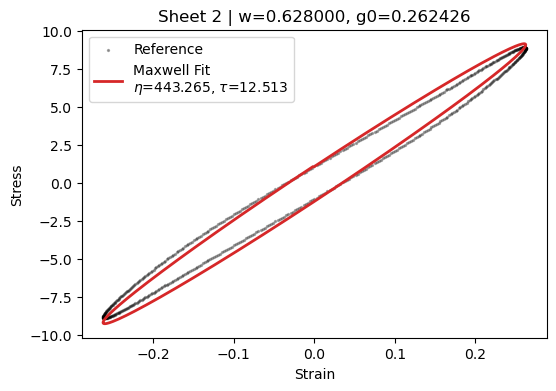

0.628rad - 0.7242789
Start Index (zero-crossing): 0


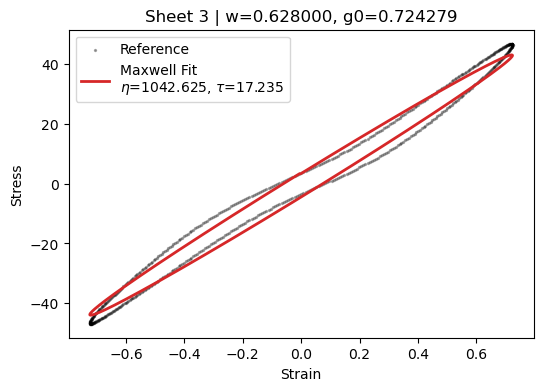

0.628rad - 3.6871027
Start Index (zero-crossing): 0


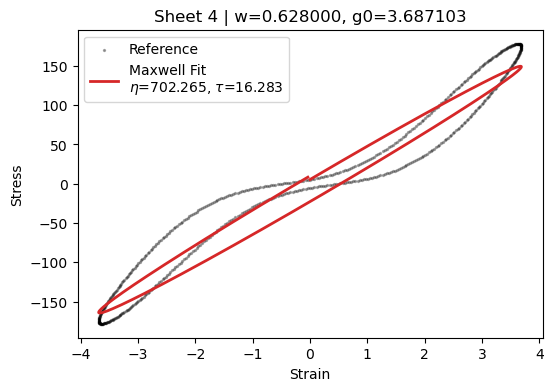

0.628rad - 0.0233958
Start Index (zero-crossing): 0


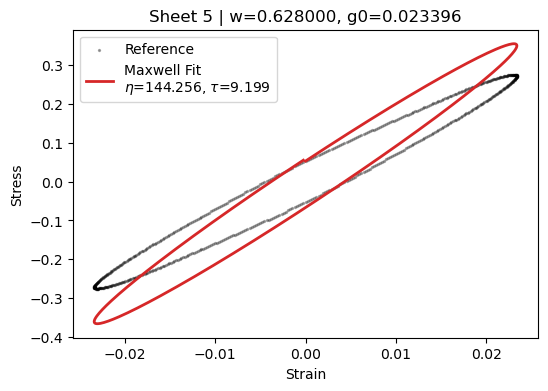

0.628rad - 0.0808714
Start Index (zero-crossing): 0


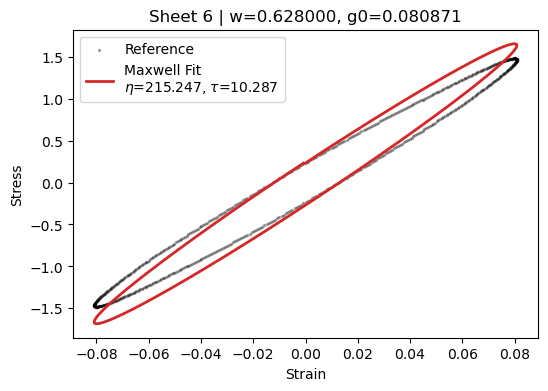

0.628rad - 0.2615977
Start Index (zero-crossing): 0


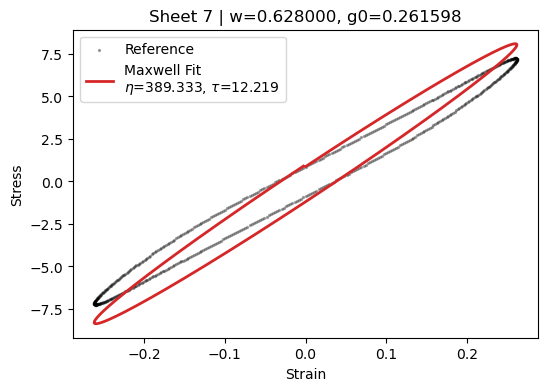

0.628rad - 0.6944665
Start Index (zero-crossing): 0


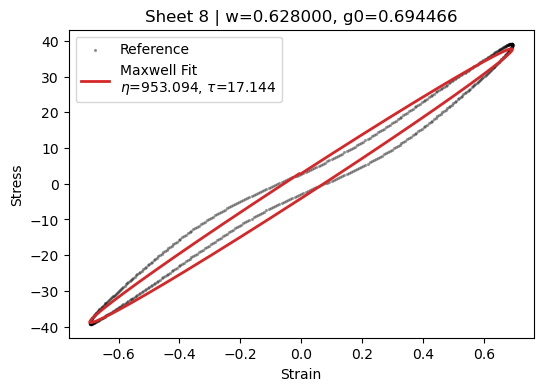

0.628rad - 3.0372883
Start Index (zero-crossing): 0


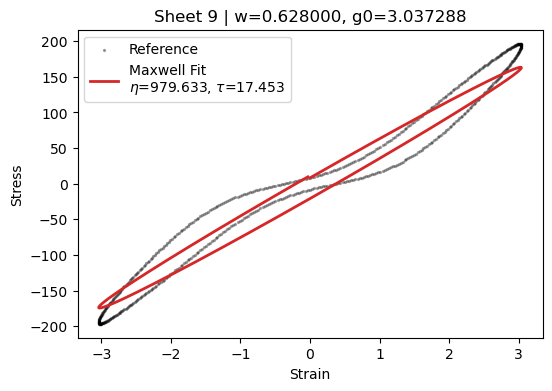

0.628rad - 0.0252134
Start Index (zero-crossing): 0


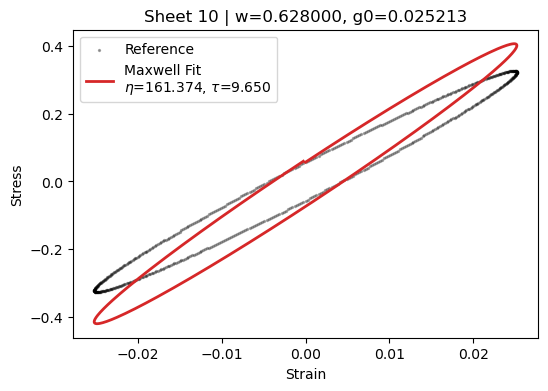

0.628rad - 0.086821
Start Index (zero-crossing): 0


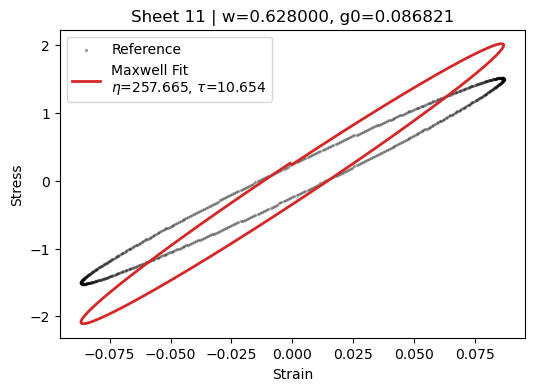

0.628rad - 0.2788382
Start Index (zero-crossing): 0


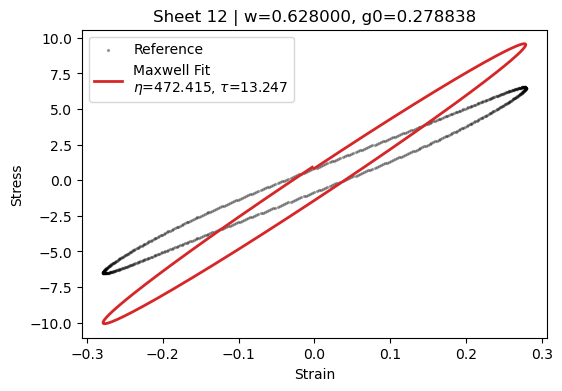

0.628rad - 0.7593773
Start Index (zero-crossing): 0


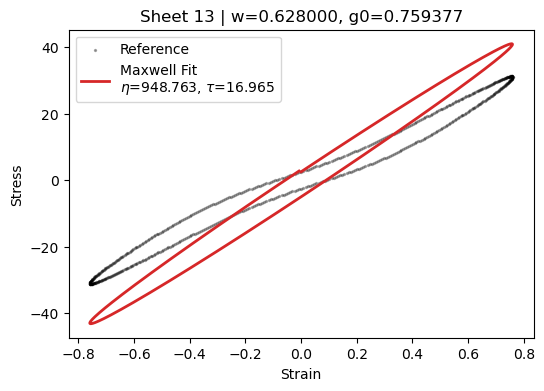

0.628rad - 4.1893049
Start Index (zero-crossing): 0


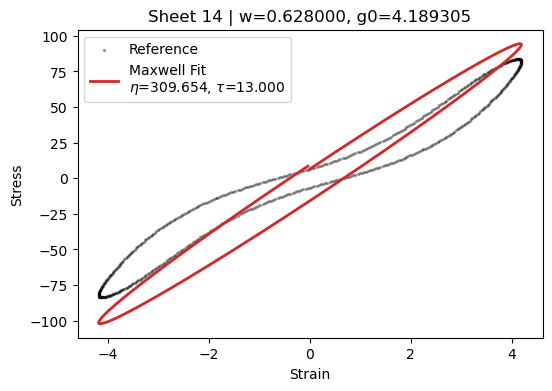

0.628rad - 0.0255513
Start Index (zero-crossing): 0


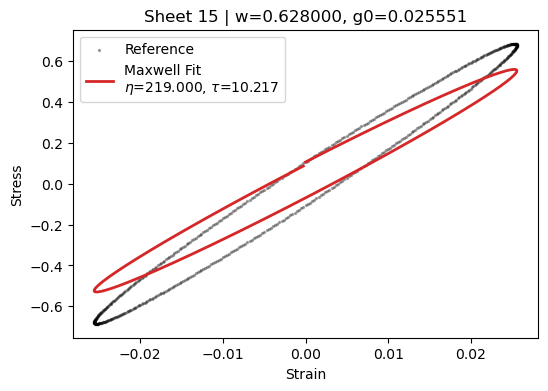

0.628rad - 0.0872575
Start Index (zero-crossing): 0


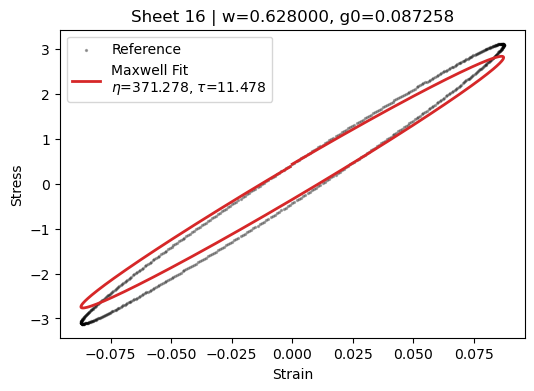

0.628rad - 0.2741326
Start Index (zero-crossing): 0


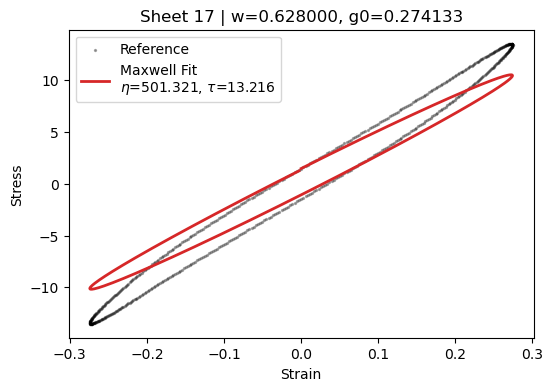

0.628rad - 0.7396461
Start Index (zero-crossing): 0


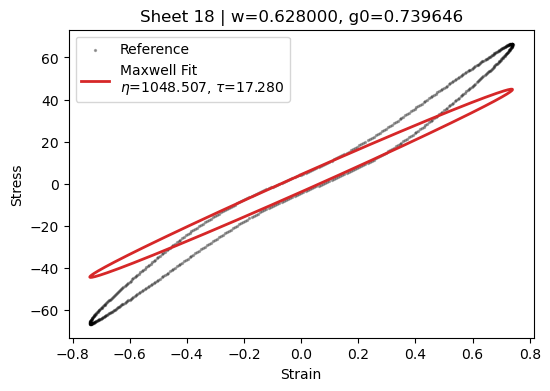

0.628rad - 2.3593654
Start Index (zero-crossing): 0


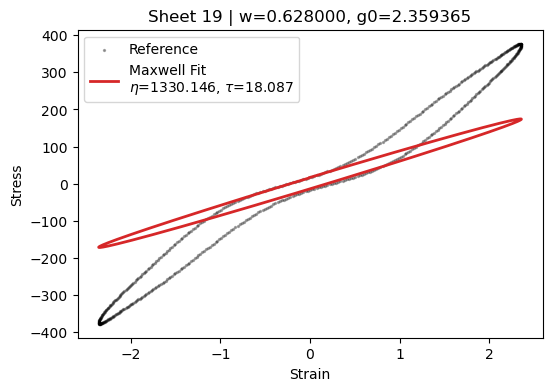

0.628rad - 0.0232108
Start Index (zero-crossing): 0


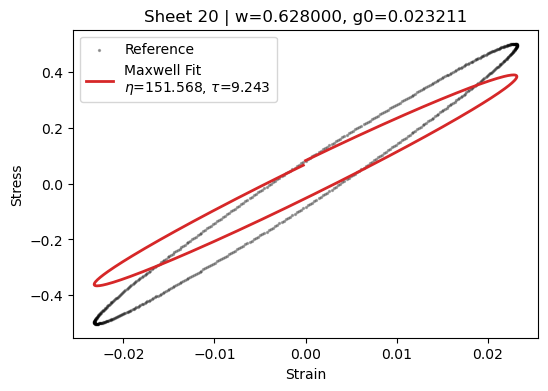

0.628rad - 0.0834978
Start Index (zero-crossing): 0


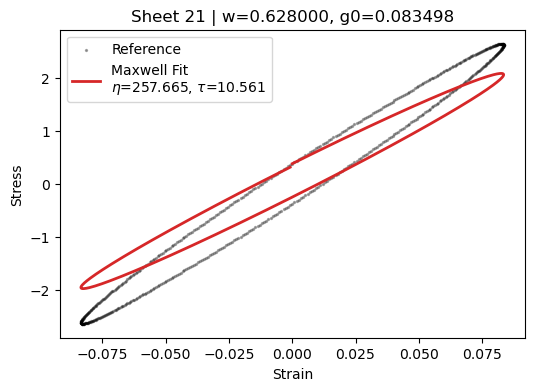

0.628rad - 0.2718309
Start Index (zero-crossing): 0


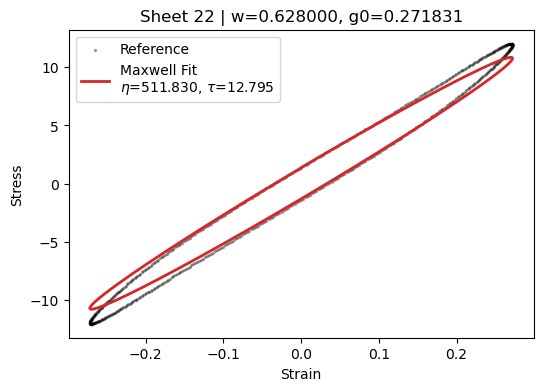

0.628rad - 0.7946087
Start Index (zero-crossing): 0


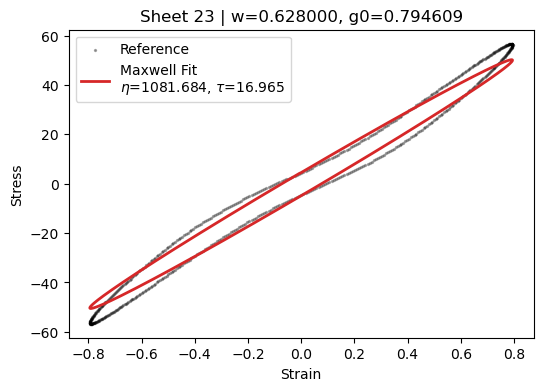

In [8]:
# y000 = y0_fit  # NOTE: Replaced with dictionary
# g00 = X_fit[:,1]
# omega0 = X_fit[:,0]
lf_set = indices
N_exp = int(10.*len(s_hf_sampled)/len(lf_set))  # Desired ratio of LF to HF data points

# Use lists, np.append is slow  
t_lf_list, g0_lf_list, w_lf_list, g_lf_list, gdot_lf_list, s_lf_list = [], [], [], [], [], []

for i in lf_set:
    t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(i)

    omega, g0 = X_fit_dict[i]
    y0 = y0_fit_dict[i]
    
    X_pred = np.reshape([omega, g0], (1,-1))
    X_pred_l = np.log(X_pred)
    eta_pred_l = best_eta_model.predict(X_pred_l)[0]
    tau_pred_l = best_tau_model.predict(X_pred_l)[0]
    eta_pred = np.exp(eta_pred_l)
    tau_pred = np.exp(tau_pred_l)

    t_pred = np.linspace(min(t_test), max(t_test), N_exp)
    Y_pred = fit_function(t_pred, eta_pred, tau_pred, y0, g0, omega, tmax=1, wmax=1)
    
    g_pred = g0 * np.sin(omega * t_pred)
    gdot_pred = g0 * np.cos(omega * t_pred)  # NOTE: Strain is normalized with respect to phase angle
    
    #LF generation
    g0_lf_list.extend(g0 * np.ones(N_exp))
    t_lf_list.extend(t_pred)
    w_lf_list.extend(omega * np.ones(N_exp))
    
    g_lf_list.extend(g_pred)
    gdot_lf_list.extend(gdot_pred)
    s_lf_list.extend(Y_pred)

    plt.figure(figsize=(6, 4))
    plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
    plt.scatter(st_test, s_test, label='Reference', s=2, color='k', alpha=0.3)
    plt.plot(g_pred, Y_pred, label=f'Maxwell Fit\n$\eta$={eta_pred:.3f}, $\\tau$={tau_pred:.3f}', linewidth=2, color='tab:red')
    plt.xlabel('Strain')
    plt.ylabel('Stress')
    plt.legend()
    plt.show()


### Exporting the Lo-Fi and Hi-Fi SAOS data
As mentioned above, and due to the time shift, the Hi-Fi data is also generated here based on the raw Hi-Fi data.

In [9]:
# Diagnostic:
# Sanity check: LF and HF strain rate max values should be comparable
# for the same omega and g0 combination
for i in range(len(data)):
    _, g0_hf, w_hf, _, _, sr_hf = extractor(i)
    omega_i = np.unique(w_hf)[0]
    g0_i = np.unique(g0_hf)[0]
    
    # LF max strain rate (after fix): g0 * 1 (since cos max = 1, no omega)
    lf_sr_max_expected = g0_i  
    # HF max strain rate from rheometer
    hf_sr_max = np.max(np.abs(sr_hf))
    
    ratio = hf_sr_max / lf_sr_max_expected
    if not (0.8 < ratio < 1.2):
        print(f"WARNING Sheet {i}: sr ratio = {ratio:.3f} — check units!")
    else:
        print(f"Sheet {i}: sr ratio OK ({ratio:.3f})")

0.628rad - 0.022122
Start Index (zero-crossing): 0
Sheet 0: sr ratio OK (0.982)
0.628rad - 0.079266
Start Index (zero-crossing): 0
Sheet 1: sr ratio OK (0.990)
0.628rad - 0.2624259
Start Index (zero-crossing): 0
Sheet 2: sr ratio OK (0.993)
0.628rad - 0.7242789
Start Index (zero-crossing): 0
Sheet 3: sr ratio OK (0.997)
0.628rad - 3.6871027
Start Index (zero-crossing): 0
Sheet 4: sr ratio OK (1.018)
0.628rad - 0.0233958
Start Index (zero-crossing): 0
Sheet 5: sr ratio OK (0.984)
0.628rad - 0.0808714
Start Index (zero-crossing): 0
Sheet 6: sr ratio OK (0.990)
0.628rad - 0.2615977
Start Index (zero-crossing): 0
Sheet 7: sr ratio OK (0.993)
0.628rad - 0.6944665
Start Index (zero-crossing): 0
Sheet 8: sr ratio OK (0.997)
0.628rad - 3.0372883
Start Index (zero-crossing): 0
Sheet 9: sr ratio OK (1.010)
0.628rad - 0.0252134
Start Index (zero-crossing): 0
Sheet 10: sr ratio OK (0.994)
0.628rad - 0.086821
Start Index (zero-crossing): 0
Sheet 11: sr ratio OK (0.995)
0.628rad - 0.2788382
Start In

In [10]:
df_LF_raw = np.column_stack([g0_lf_list, t_lf_list,
                             w_lf_list, g_lf_list,
                             gdot_lf_list, s_lf_list])
df_LF = pd.DataFrame(df_LF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_LF.to_excel("Data_LF_SAOS_pig_negcon.xlsx", index=False)
df_HF_raw = np.column_stack([g0_hf_sampled, t_hf_sampled,
                             w_hf_sampled, g_hf_sampled,
                             gdot_hf_sampled, s_hf_sampled])
df_HF = pd.DataFrame(df_HF_raw, columns = ['G0','Time', 'AngFreq', 'Strain', 'StrainRate', 'Stress'])
df_HF.to_excel("Data_HF_SAOS_pig_negcon.xlsx", index=False)

In [11]:
# Diagnostic:
# In Notebook 1, after loading data for sheet i:
t, g0, w, s, st, sr = extractor(0)
omega = np.unique(w)[0]
g0_val = np.unique(g0)[0]
sr_theoretical = g0_val * omega * np.cos(omega * t)
sr_theoretical_norm = g0_val * np.cos(omega * t)  # if divided by omega
print("Max sr (raw):", np.max(sr))
print("Max sr_theoretical:", np.max(sr_theoretical))
print("Max sr_theoretical/omega:", np.max(sr_theoretical_norm))
# Whichever matches sr is what the rheometer outputs

0.628rad - 0.022122
Start Index (zero-crossing): 0
Max sr (raw): 0.02172
Max sr_theoretical: 0.013892616
Max sr_theoretical/omega: 0.022122


In [12]:
# ===== DIAGNOSTIC 1: Check Maxwell fit quality at low vs high amplitudes =====
for i in range(len(data)):
    t, g0, w, s, st, sr = extractor(i)
    omega = np.unique(w)[0]
    g0_val = np.unique(g0)[0]
    eta, tau = Y_fit_dict[i]
    
    # Compute R² of Maxwell fit
    y_pred = fit_function(t, eta, tau, s[0], g0_val, omega, 1, 1)
    ss_res = np.sum((np.array(s) - y_pred)**2)
    ss_tot = np.sum((np.array(s) - np.mean(s))**2)
    r2 = 1 - ss_res/ss_tot
    print(f"Sheet {i}: g0={g0_val:.4f}, omega={omega:.4f}, R²={r2:.4f}")

# ===== DIAGNOSTIC 2: Check LF vs HF stress range =====
print("LF stress range:", np.min(s_lf_list), np.max(s_lf_list))
print("HF stress range:", np.min(s_hf_sampled), np.max(s_hf_sampled))

# ===== DIAGNOSTIC 3: Check strain rate units =====
t, g0, w, s, st, sr = extractor(0)
omega = np.unique(w)[0]; g0_val = np.unique(g0)[0]
print("sr max (data):", np.max(np.abs(sr)))
print("g0*omega:", g0_val * omega)
print("g0 alone:", g0_val)



0.628rad - 0.022122
Start Index (zero-crossing): 0
Sheet 0: g0=0.0221, omega=0.6280, R²=0.9999
0.628rad - 0.079266
Start Index (zero-crossing): 0
Sheet 1: g0=0.0793, omega=0.6280, R²=1.0000
0.628rad - 0.2624259
Start Index (zero-crossing): 0
Sheet 2: g0=0.2624, omega=0.6280, R²=0.9994
0.628rad - 0.7242789
Start Index (zero-crossing): 0
Sheet 3: g0=0.7243, omega=0.6280, R²=0.9957
0.628rad - 3.6871027
Start Index (zero-crossing): 0
Sheet 4: g0=3.6871, omega=0.6280, R²=0.9647
0.628rad - 0.0233958
Start Index (zero-crossing): 0
Sheet 5: g0=0.0234, omega=0.6280, R²=0.9999
0.628rad - 0.0808714
Start Index (zero-crossing): 0
Sheet 6: g0=0.0809, omega=0.6280, R²=1.0000
0.628rad - 0.2615977
Start Index (zero-crossing): 0
Sheet 7: g0=0.2616, omega=0.6280, R²=0.9993
0.628rad - 0.6944665
Start Index (zero-crossing): 0
Sheet 8: g0=0.6945, omega=0.6280, R²=0.9955
0.628rad - 3.0372883
Start Index (zero-crossing): 0
Sheet 9: g0=3.0373, omega=0.6280, R²=0.9798
0.628rad - 0.0252134
Start Index (zero-cro